###Notebook Strucutre 

1. Import Libraries
2. Load Datasets
3. Initial Data Inspection
4. Data Types and Data Cleaning
5. Descriptive Statistics
6. Missing Values Analysis
7. Feature Engineering (Customer Lifecycle)
8. Visualization 1 – Churn Distribution
9. Visualization 2 – Electricity Consumption Distribution
10. Visualization 3 – Customer Tenure Distribution
11. Visualization 4 – Energy Price Distribution
12. Visualization 5 – Correlation Heatmap
13. Visualization 6 – Electricity Consumption vs Churn
14. Visualization 7 – Price vs Churn
15. Visualization 8 – Price Trend Over Time
16. Advanced Analysis – Churn Rate by Consumption Segment
17. Price Sensitivity and Churn Insights

## Import Libraries

In [1]:
# Import libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve visual style
sns.set(style="whitegrid")

## Load the Datasets

In [5]:
# Load client dataset
client_data = pd.read_csv("client_data.csv")

# Load pricing dataset
price_data = pd.read_csv("price_data.csv")

# Preview datasets
client_data.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [6]:

price_data.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## Dataset Shape

In [7]:
print("Client dataset shape:", client_data.shape)
print("Price dataset shape:", price_data.shape)

Client dataset shape: (14606, 26)
Price dataset shape: (193002, 8)


## Column Names

In [8]:
print("Client dataset columns:")
print(client_data.columns)

print("\nPrice dataset columns:")
print(price_data.columns)

Client dataset columns:
Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='object')

Price dataset columns:
Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')


## Data Types

In [9]:
client_data.dtypes

id                                 object
channel_sales                      object
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                         object
date_end                           object
date_modif_prod                    object
date_renewal                       object
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                            object
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64
num_years_antig                     int64
origin_up                         

In [10]:
price_data.dtypes

id                     object
price_date             object
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

## Convert Date Columns

In [11]:
# Convert date columns to datetime format

date_columns = ['date_activ','date_end','date_modif_prod','date_renewal']

for col in date_columns:
    client_data[col] = pd.to_datetime(client_data[col])

## Descriptive Statistics

In [12]:
client_data.describe()

,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912448,2016-07-27 20:48:26.422018560,2013-01-02 12:29:10.951663872,2015-07-21 06:59:00.353279488,1868.614880,1399.762906,0.966726,...,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,...,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,...,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,...,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,...,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,...,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175


In [13]:
price_data.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


## Missing Values

In [14]:
client_data.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [15]:
price_data.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

## Unique Values

In [16]:
client_data.nunique()

id                                14606
channel_sales                         8
cons_12m                          11065
cons_gas_12m                       2112
cons_last_month                    4751
date_activ                         1796
date_end                            368
date_modif_prod                    2129
date_renewal                        386
forecast_cons_12m                 13993
forecast_cons_year                 4218
forecast_discount_energy             12
forecast_meter_rent_12m            3528
forecast_price_energy_off_peak      516
forecast_price_energy_peak          329
forecast_price_pow_off_peak          41
has_gas                               2
imp_cons                           7752
margin_gross_pow_ele               2391
margin_net_pow_ele                 2391
nb_prod_act                          10
net_margin                        11965
num_years_antig                      13
origin_up                             6
pow_max                             698


## Feature Engineering (Customer Lifecycle)

In [17]:
# Create reference date
today = pd.Timestamp.today()

# Customer tenure
client_data["customer_tenure_days"] = (today - client_data["date_activ"]).dt.days

# Days until contract renewal
client_data["days_to_renewal"] = (client_data["date_renewal"] - today).dt.days

# Days since last product modification
client_data["days_since_modification"] = (today - client_data["date_modif_prod"]).dt.days

## Visualization 1 — Churn Distribution

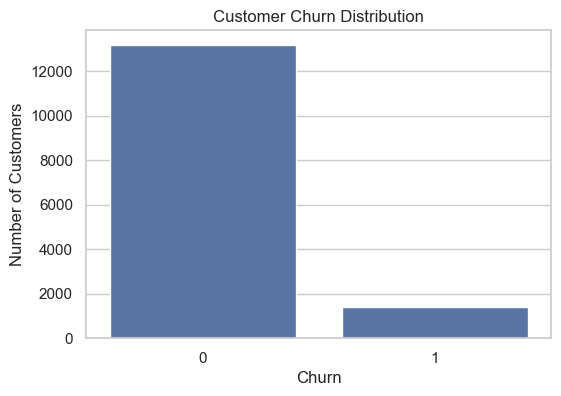

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=client_data)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Visualization 2 — Electricity Consumption Distribution

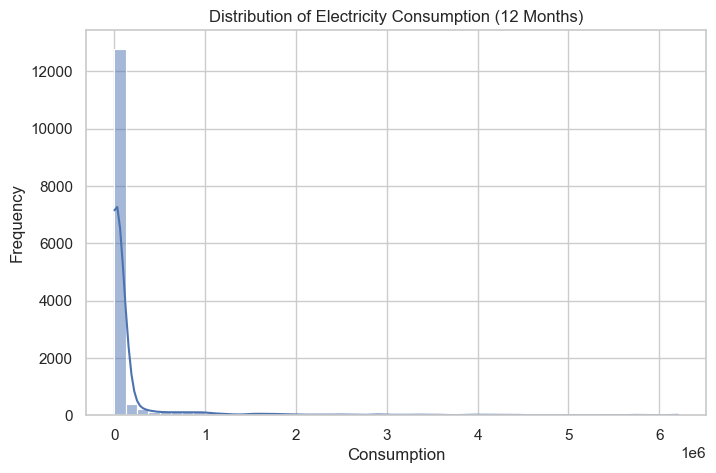

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(client_data["cons_12m"], bins=50, kde=True)

plt.title("Distribution of Electricity Consumption (12 Months)")
plt.xlabel("Consumption")
plt.ylabel("Frequency")

plt.show()

## Visualization 3 — Customer Tenure Distribution

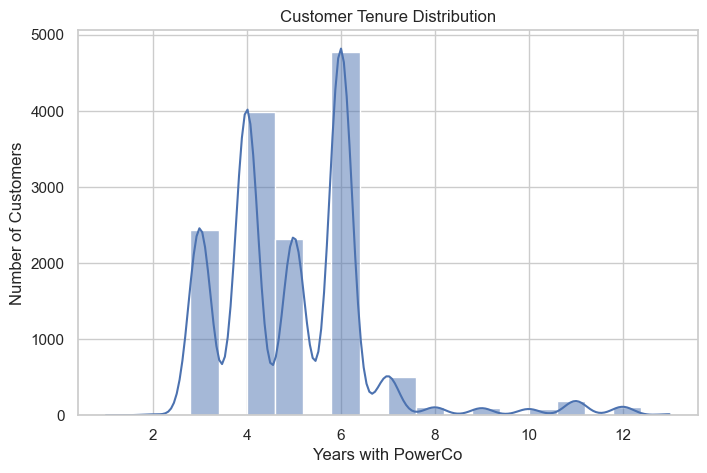

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(client_data["num_years_antig"], bins=20, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Years with PowerCo")
plt.ylabel("Number of Customers")

plt.show()

## Visualization 4 — Energy Price Distribution

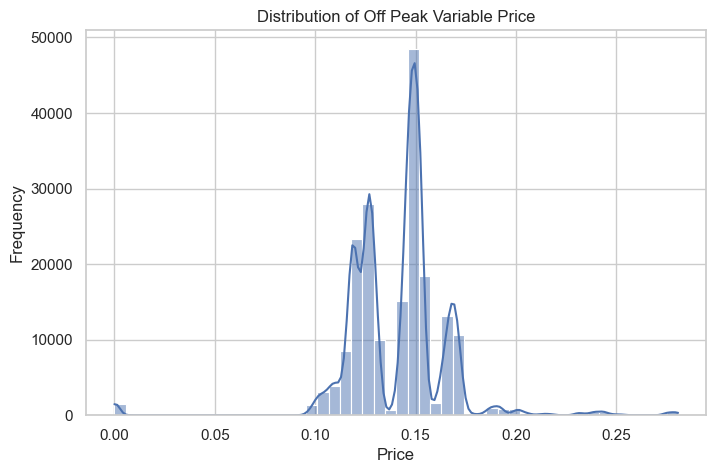

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(price_data["price_off_peak_var"], bins=50, kde=True)

plt.title("Distribution of Off Peak Variable Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## Visualization 5 — Correlation Heatmap

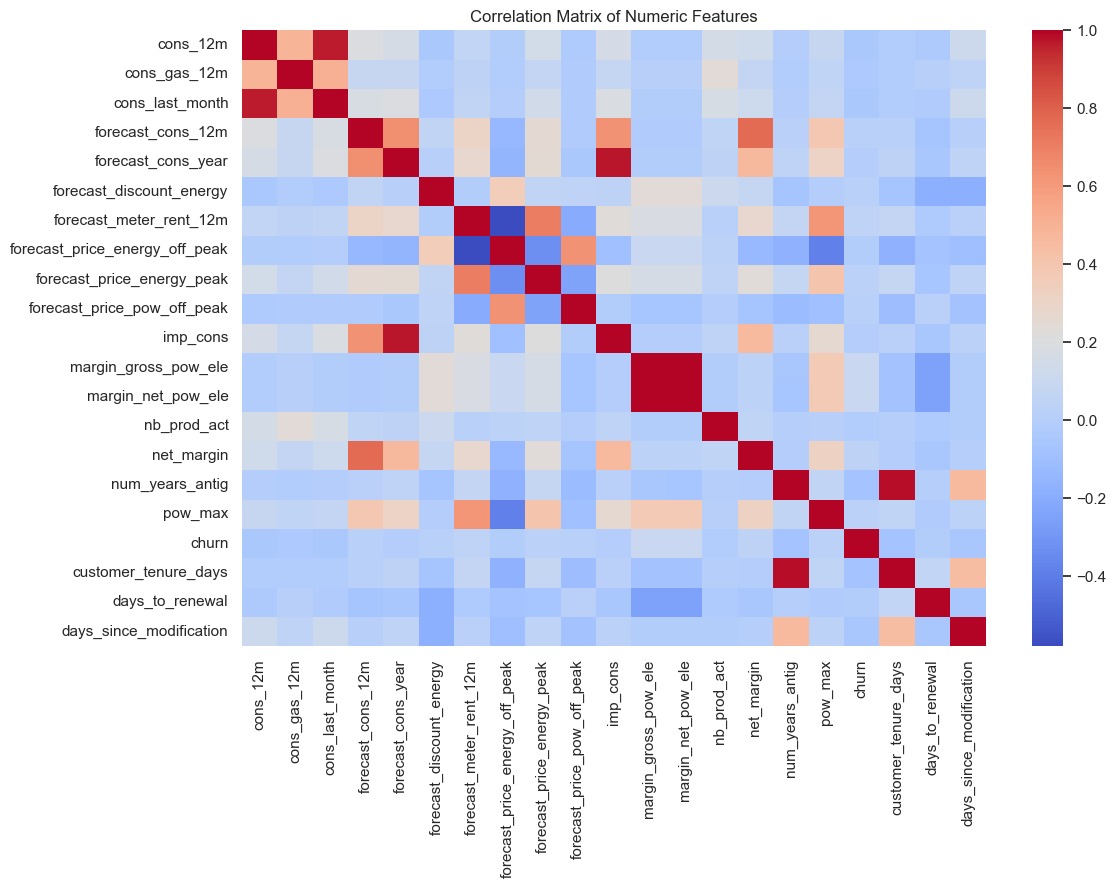

In [24]:
# Select only numeric columns
numeric_data = client_data.select_dtypes(include=['int64','float64'])

# Compute correlation matrix
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix of Numeric Features")

plt.show()

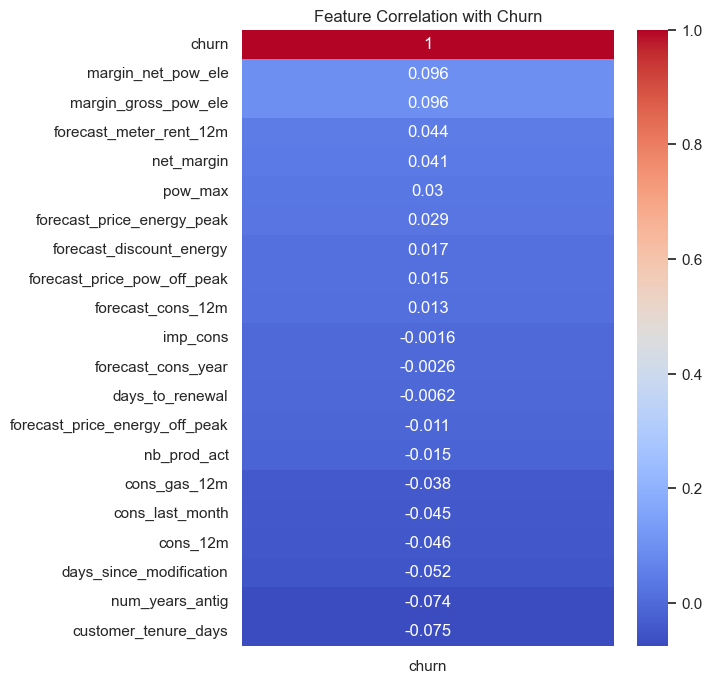

In [25]:
# Correlation with churn only
corr_churn = numeric_data.corr()["churn"].sort_values(ascending=False)

plt.figure(figsize=(6,8))

sns.heatmap(corr_churn.to_frame(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation with Churn")

plt.show()

## Visualization 6 — Consumption vs Churn

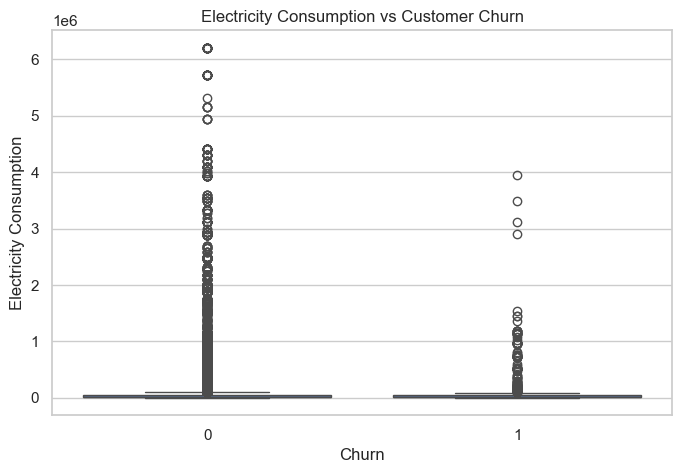

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="churn", y="cons_12m", data=client_data)

plt.title("Electricity Consumption vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Electricity Consumption")

plt.show()

## Visualization 7 — Price vs Churn

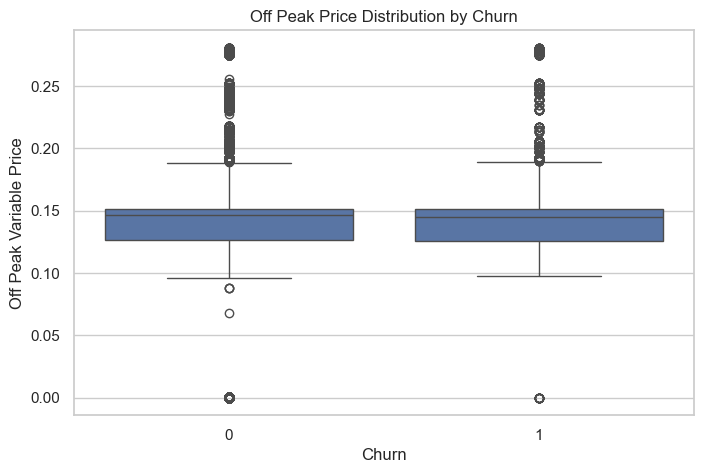

In [27]:
# Merge datasets

merged_data = pd.merge(client_data, price_data, on="id", how="left")

plt.figure(figsize=(8,5))

sns.boxplot(x="churn", y="price_off_peak_var", data=merged_data)

plt.title("Off Peak Price Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Off Peak Variable Price")

plt.show()

## Visualization 8 — Price Trend Over Time

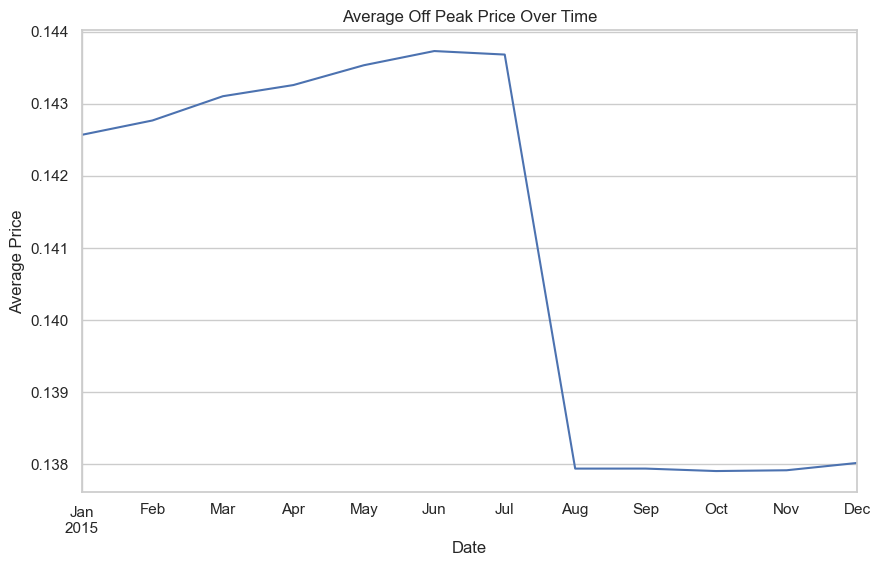

In [28]:
price_data["price_date"] = pd.to_datetime(price_data["price_date"])

plt.figure(figsize=(10,6))

price_data.groupby("price_date")["price_off_peak_var"].mean().plot()

plt.title("Average Off Peak Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")

plt.show()

## Advanced Analysis — Churn Rate by Consumption Segment

Create Segments

In [29]:
client_data["consumption_segment"] = pd.qcut(
    client_data["cons_12m"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

Calculate Churn Rate

In [31]:
churn_by_segment = client_data.groupby("consumption_segment", observed=False)["churn"].mean()

churn_by_segment

consumption_segment
Low          0.093373
Medium       0.098329
High         0.099699
Very High    0.097207
Name: churn, dtype: float64

Visualize Churn Rate

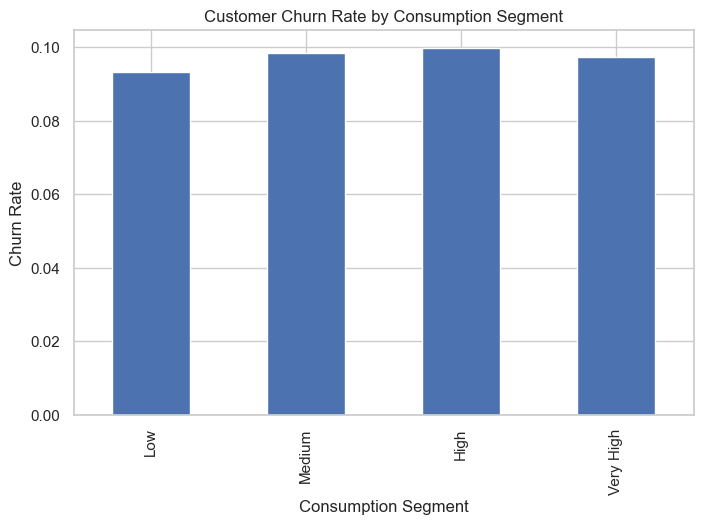

In [32]:
plt.figure(figsize=(8,5))

churn_by_segment.plot(kind="bar")

plt.title("Customer Churn Rate by Consumption Segment")
plt.xlabel("Consumption Segment")
plt.ylabel("Churn Rate")

plt.show()

## Price Sensitivity and Churn Insights

Key Insights from Exploratory Data Analysis are as follows: 

1. Customer Churn Distribution

The dataset shows that the number of churned customers is smaller than the number of retained customers, indicating a moderate class imbalance that should be considered during predictive modeling.

2. Electricity Consumption

Electricity consumption exhibits a right-skewed distribution where most customers consume relatively small amounts of electricity while a minority of customers exhibit significantly higher consumption levels.

3. Customer Tenure

Customer tenure varies significantly across the dataset, suggesting that both newly acquired and long-standing customers are represented. Further investigation may reveal whether newer customers have a higher probability of churn.

4. Energy Pricing

Energy price distributions appear relatively stable with moderate variation across customers. While price differences exist, the range of prices suggests structured pricing within the market.

5. Price Sensitivity and Churn

Comparative analysis between churned and non-churned customers indicates potential pricing differences, suggesting that customers paying higher prices may exhibit a greater likelihood of switching providers.

6. Consumption Segmentation

Segment analysis shows variation in churn rates across electricity consumption levels. Lower consumption customers tend to show higher churn rates compared to higher consumption customers, suggesting that smaller customers may be more price sensitive.

7. Correlation Analysis

Correlation analysis indicates relatively weak direct relationships between individual variables and churn, suggesting that customer churn is likely driven by a combination of multiple interacting factors rather than a single dominant variable.

#### Final Consulting Insights

1. Price differences exist between churned and retained customers, suggesting that some customers may be sensitive to pricing changes.

2. However, the relationship between price and churn appears relatively weak, indicating that price alone may not fully explain why customers leave.

3. Electricity consumption patterns show that lower-consumption customers tend to exhibit higher churn rates, suggesting they may be more price sensitive.

4. Customer tenure may also influence churn, as newer customers could be more likely to switch providers compared to long-term customers.

5. Overall, the exploratory analysis suggests that customer churn is likely driven by multiple factors, including pricing, consumption behavior, and customer lifecycle characteristics.